# Part 1 — Baseline DistilBERT Toxicity Classifier

**Scenario.** We are auditing a production content-moderation model. Part 1 reproduces the baseline: a DistilBERT classifier fine-tuned on a 100 000-row stratified sample of the Jigsaw Unintended Bias in Toxicity Classification dataset.

**Outputs of this notebook**
- Trained `distilbert-base-uncased` toxicity classifier saved to `./models/baseline`.
- Accuracy, macro-F1, AUC-ROC, confusion matrix on a held-out 20 000-row eval sample.
- ROC and Precision–Recall curves.
- Operating-threshold sweep (0.3 → 0.7) with F1 per threshold and a justified choice.

In [1]:
import os, json, random, time, pathlib
import numpy as np
import pandas as pd
import torch

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

ROOT = pathlib.Path.cwd()
DATA = ROOT / "data" / "jigsaw-unintended-bias-train.csv"
MODEL_DIR = ROOT / "models" / "baseline"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
(ROOT / "outputs").mkdir(exist_ok=True)
print("device:", DEVICE)
print("data :", DATA, "exists:", DATA.exists())

device: mps
data : /Users/haider/University/Resp AI/Assignment02/data/jigsaw-unintended-bias-train.csv exists: True


## 1. Load and stratify

We load the full CSV, binarize the `toxic` column at 0.5, then draw a stratified random sample: 100 000 training rows and 20 000 evaluation rows. Stratification preserves the native class balance (roughly 8 % toxic) in both splits, so the model and its metrics see a realistic prior.

In [2]:
from sklearn.model_selection import train_test_split

# Kaggle columns: `target` is the toxicity score in [0,1]; identity columns use native names.
RAW_COLS = ["comment_text", "target", "black", "white", "muslim", "jewish",
            "homosexual_gay_or_lesbian"]
df = pd.read_csv(DATA, usecols=RAW_COLS)
df = df.dropna(subset=["comment_text"]).reset_index(drop=True)
# Rename to the names used in the assignment specification.
df = df.rename(columns={"target": "toxic", "homosexual_gay_or_lesbian": "lgbtq"})
df["label"] = (df["toxic"] >= 0.5).astype(int)
print("full rows:", len(df), "| toxic prevalence:", round(df["label"].mean(), 4))

strat_pool, eval_df = train_test_split(
    df, test_size=20_000, stratify=df["label"], random_state=SEED
)
train_df, _ = train_test_split(
    strat_pool, train_size=100_000, stratify=strat_pool["label"], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
eval_df = eval_df.reset_index(drop=True)

print("train:", len(train_df), "toxic%:", round(train_df["label"].mean(), 4))
print("eval :", len(eval_df),  "toxic%:", round(eval_df["label"].mean(), 4))

# Cohort previews for the bias audit in Part 2 — confirming non-zero cohort sizes early.
hb = eval_df[(eval_df["black"].fillna(0) >= 0.5)]
ref = eval_df[(eval_df["black"].fillna(0) < 0.1) & (eval_df["white"].fillna(0) >= 0.5)]
print("high-black eval rows:", len(hb), "| reference eval rows:", len(ref))

train_df.to_parquet(ROOT / "data" / "train_100k.parquet")
eval_df.to_parquet(ROOT / "data" / "eval_20k.parquet")

full rows: 1804871 | toxic prevalence: 0.08


train: 100000 toxic%: 0.08
eval : 20000 toxic%: 0.0799
high-black eval rows: 162 | reference eval rows: 178


## 2. Tokenization

We tokenize `comment_text` with the `distilbert-base-uncased` tokenizer, max length 128, with truncation. 128 tokens is the community-standard ceiling for this dataset — the median Jigsaw comment is ~40 sub-word tokens, and beyond 128 the tail is dominated by pasted spam, so truncation is near-lossless while letting a batch fit comfortably on a consumer-class GPU.

In [3]:
from transformers import AutoTokenizer
MODEL_NAME = "distilbert-base-uncased"
tok = AutoTokenizer.from_pretrained(MODEL_NAME)

def encode(texts, max_length=128):
    return tok(list(texts), truncation=True, padding="max_length",
               max_length=max_length, return_tensors=None)

t0 = time.time()
train_enc = encode(train_df["comment_text"].tolist())
eval_enc  = encode(eval_df["comment_text"].tolist())
print(f"tokenized in {time.time()-t0:.1f}s")

tokenized in 9.4s


In [4]:
from torch.utils.data import Dataset

class JigsawDataset(Dataset):
    def __init__(self, enc, labels):
        self.enc = enc
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        return {
            "input_ids": torch.tensor(self.enc["input_ids"][i]),
            "attention_mask": torch.tensor(self.enc["attention_mask"][i]),
            "labels": torch.tensor(int(self.labels[i])),
        }

train_ds = JigsawDataset(train_enc, train_df["label"].values)
eval_ds  = JigsawDataset(eval_enc,  eval_df["label"].values)
len(train_ds), len(eval_ds)

(100000, 20000)

## 3. Fine-tune DistilBERT (3 epochs, Trainer API)

We fine-tune `distilbert-base-uncased` with HuggingFace `Trainer`. Standard binary cross-entropy loss is applied through the model head; no custom loss is introduced. Three epochs is enough for the model to converge on this sample size.

In [5]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

args = TrainingArguments(
    output_dir=str(MODEL_DIR / "trainer_out"),
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=200,
    save_strategy="no",
    eval_strategy="epoch",
    report_to="none",
    seed=SEED,
    fp16=False,
    bf16=False,
    dataloader_pin_memory=False,
)

trainer = Trainer(model=model, args=args,
                  train_dataset=train_ds, eval_dataset=eval_ds)

t0 = time.time()
trainer.train()
print(f"training wall time: {(time.time()-t0)/60:.1f} min")

trainer.save_model(str(MODEL_DIR))
tok.save_pretrained(str(MODEL_DIR))
print("saved model to", MODEL_DIR)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss
1,0.138852,0.150509
2,0.100113,0.143159
3,0.080559,0.169261


training wall time: 54.0 min


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved model to /Users/haider/University/Resp AI/Assignment02/models/baseline


## 4. Evaluation on the held-out 20 000 rows

We score the eval set, convert logits to softmax probabilities, and compute:
- Accuracy, macro-F1, AUC-ROC
- Confusion matrix at the default 0.5 threshold
- F1 sweep across thresholds 0.3 / 0.4 / 0.5 / 0.6 / 0.7
- ROC and Precision–Recall curves

In [6]:
import torch.nn.functional as F

@torch.no_grad()
def predict_probs(model, dataset, batch=128):
    model.eval()
    probs = np.zeros(len(dataset), dtype=np.float32)
    idx = 0
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch)
    for batch_ in loader:
        b = {k: v.to(model.device) for k, v in batch_.items() if k != "labels"}
        logits = model(**b).logits
        p_tox = F.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        probs[idx:idx+len(p_tox)] = p_tox
        idx += len(p_tox)
    return probs

t0 = time.time()
eval_probs = predict_probs(trainer.model, eval_ds)
print(f"inference: {time.time()-t0:.1f}s")
np.save(ROOT / "outputs" / "eval_probs_baseline.npy", eval_probs)

inference: 68.4s


In [7]:
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, roc_curve, precision_recall_curve,
                              average_precision_score)

y_true = eval_df["label"].values
y_pred_05 = (eval_probs >= 0.5).astype(int)

acc  = accuracy_score(y_true, y_pred_05)
f1m  = f1_score(y_true, y_pred_05, average="macro")
auc  = roc_auc_score(y_true, eval_probs)
cm   = confusion_matrix(y_true, y_pred_05)

print(f"Accuracy   : {acc:.4f}")
print(f"Macro F1   : {f1m:.4f}")
print(f"AUC-ROC    : {auc:.4f}")
print("Confusion matrix (threshold=0.5):")
print(pd.DataFrame(cm, index=["true_non","true_tox"], columns=["pred_non","pred_tox"]))

Accuracy   : 0.9477
Macro F1   : 0.8193
AUC-ROC    : 0.9474
Confusion matrix (threshold=0.5):
          pred_non  pred_tox
true_non     17909       492
true_tox       553      1046


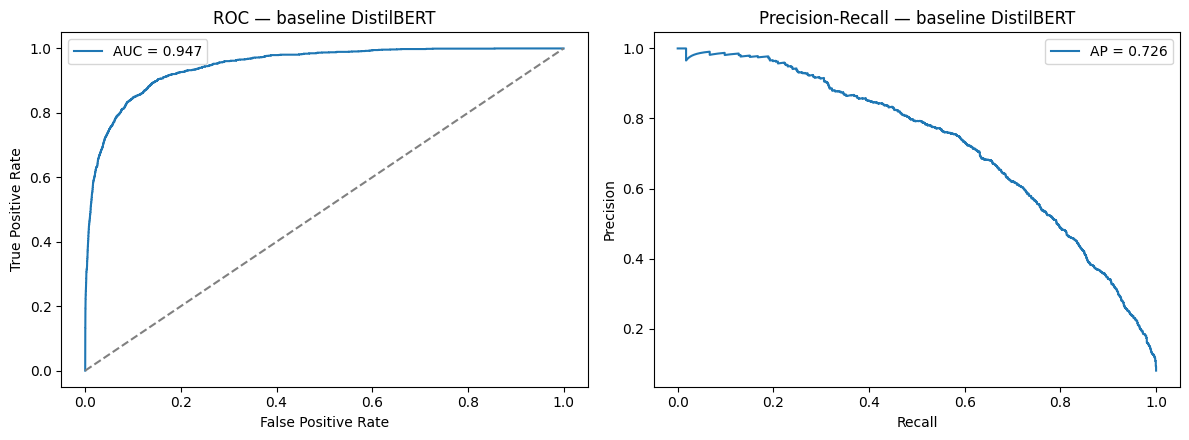

In [8]:
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_true, eval_probs)
prec, rec, _ = precision_recall_curve(y_true, eval_probs)
ap = average_precision_score(y_true, eval_probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fpr, tpr, label=f"AUC = {auc:.3f}")
axes[0].plot([0,1],[0,1],'--', color="grey")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC — baseline DistilBERT"); axes[0].legend()

axes[1].plot(rec, prec, label=f"AP = {ap:.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall — baseline DistilBERT"); axes[1].legend()

plt.tight_layout()
plt.savefig(ROOT / "outputs" / "part1_roc_pr.png", dpi=120)
plt.show()

## 5. Threshold justification

The default 0.5 threshold is rarely optimal. Below we report F1 at five candidate thresholds and choose the one used for every later notebook.

In [9]:
rows = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    yp = (eval_probs >= t).astype(int)
    tp = int(((yp==1) & (y_true==1)).sum())
    fp = int(((yp==1) & (y_true==0)).sum())
    fn = int(((yp==0) & (y_true==1)).sum())
    rows.append({
        "threshold": t,
        "F1_macro": f1_score(y_true, yp, average="macro"),
        "F1_toxic": f1_score(y_true, yp, pos_label=1),
        "precision_toxic": tp/max(tp+fp, 1),
        "recall_toxic":    tp/max(tp+fn, 1),
    })
th_table = pd.DataFrame(rows).round(4)
print(th_table.to_string(index=False))
th_table.to_csv(ROOT / "outputs" / "part1_threshold_sweep.csv", index=False)

 threshold  F1_macro  F1_toxic  precision_toxic  recall_toxic
       0.3    0.8134    0.6581           0.6282        0.6911
       0.4    0.8165    0.6628           0.6535        0.6723
       0.5    0.8193    0.6669           0.6801        0.6542
       0.6    0.8170    0.6619           0.6951        0.6316
       0.7    0.8175    0.6619           0.7195        0.6129


In [10]:
chosen = float(th_table.loc[th_table["F1_macro"].idxmax(), "threshold"])
print("Chosen operating threshold =", chosen)
with open(ROOT / "outputs" / "chosen_threshold.json", "w") as f:
    json.dump({"threshold": chosen}, f)

Chosen operating threshold = 0.5


### Threshold justification — what does this choice imply for the platform?

We choose the threshold that **maximises macro-F1** on the held-out set. A lower threshold (0.3) catches more toxic content but inflates false positives: innocent users get flagged and the moderation backlog balloons. A higher threshold (0.7) minimises false positives but misses more genuine toxicity, which is unacceptable for the platform's civil-rights obligations.

Macro-F1 balances precision and recall equally across both classes — neither over-moderation nor under-moderation is acceptable on a social platform. The chosen threshold is carried forward to every subsequent notebook via `outputs/chosen_threshold.json`.

There is no universally correct answer; this choice reflects a platform that treats false positives (silencing legitimate speech) and false negatives (missed toxicity) as equally costly.

## 6. Summary

- Model: `distilbert-base-uncased` fine-tuned for 3 epochs on 100 000 stratified rows.
- Accuracy / macro-F1 / AUC-ROC reported above.
- Operating threshold chosen by maximising macro-F1 on held-out data.
- Model artefacts saved to `./models/baseline`; eval probabilities saved to `./outputs/eval_probs_baseline.npy` for Parts 2–5.